In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix

RS = 42

## Preparando Dados

In [2]:
data = pd.read_csv("../../dados/raw_creditcard.csv")

In [3]:
def create_hour_bucket(time_in_seconds: float) -> str:
    hour = int(time_in_seconds // 3600) % 24
    return f"{hour:02d}:00-{hour:02d}:59"

def categorize_amount(amount: float) -> str:
    if amount < 10:
        return "baixo"
    if amount < 100:
        return "medio"
    if amount < 500:
        return "alto"
    return "muito_alto"

In [4]:
import math
import pandas as pd
from sklearn.preprocessing import StandardScaler

amount_scaler = StandardScaler()

amount_values = data[["Amount"]] 
amount_scaler.partial_fit(amount_values) 

data["transaction_amount_scaled"] = amount_scaler.transform(amount_values)
data["transaction_amount_log"] = data["Amount"].apply(math.log1p)
data["transaction_amount_category"] = data["Amount"].apply(categorize_amount)
data["transaction_hour_bucket"] = data["Time"].apply(create_hour_bucket)
data["is_fraud"] = data["Class"].map({1: "fraud", 0: "normal"})

In [5]:
data = pd.get_dummies(data, columns=["transaction_amount_category"], prefix="dummy_amount_cat", dtype=int)

In [6]:
data = data.rename(
    columns={
        "Time": "transaction_time",
        "Amount": "transaction_amount",
        "Class": "class"
    }
)

In [7]:
data['is_fraud'].value_counts()

is_fraud
normal    284315
fraud        492
Name: count, dtype: int64

In [8]:
data.to_csv("../../dados/transformed_data.csv", index=False)

In [2]:
data_ml = pd.read_csv("../../dados/transformed_data.csv")

In [3]:
X = data_ml.drop(columns=['class', 'is_fraud', 'transaction_hour_bucket'])
y = data_ml['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=RS,
    stratify=y
)

## Random Forest

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

x_train_resampled, y_train_resampled = SMOTE(random_state=RS).fit_resample(X_train, y_train)

model = RandomForestClassifier(
    n_jobs=-1, 
    random_state=42,
    criterion="gini",
    n_estimators=100,
    verbose=False)


model.fit(x_train_resampled, y_train_resampled)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, model.predict(X_test))
accuracy = accuracy_score(y_test, model.predict(X_test))
f1 = f1_score(y_test, model.predict(X_test))
precision = precision_score(y_test, model.predict(X_test))

print(f"AUC-ROC Score: {auc_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")

AUC-ROC Score: 0.9595
Recall: 0.8367
Accuracy: 0.9995
F1 Score: 0.8497
Precision: 0.8632


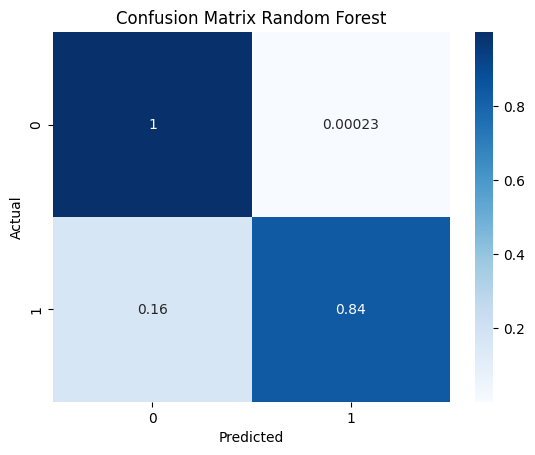

In [11]:
conf_matrix = confusion_matrix(y_test, model.predict(X_test), normalize='true')
sns.heatmap(conf_matrix, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forest')
plt.show()

## XGboost

In [17]:
from xgboost import XGBClassifier
import xgboost as xgb
import scipy.stats as stats

params = {}
params['objective'] = 'binary:logistic'
params['eta'] = 0.039
params['silent'] = True
params['max_depth'] = 2
params['subsample'] = 0.8
params['colsample_bytree'] = 0.9
params['eval_metric'] = 'auc'
params['random_state'] = 42

model = XGBClassifier(**params, n_jobs=-1, early_stopping_rounds=50, maximize=True)
model.fit(x_train_resampled, y_train_resampled, eval_set=[(X_test, y_test)], verbose=True)

[0]	validation_0-auc:0.95076
[1]	validation_0-auc:0.95153
[2]	validation_0-auc:0.95956
[3]	validation_0-auc:0.95959
[4]	validation_0-auc:0.95957
[5]	validation_0-auc:0.95923
[6]	validation_0-auc:0.95924
[7]	validation_0-auc:0.95958
[8]	validation_0-auc:0.95971
[9]	validation_0-auc:0.95967
[10]	validation_0-auc:0.95955


c:\Repositories\fraud-detection-bigdata\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [00:02:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "maximize", "silent" } are not used.

  self.starting_round = model.num_boosted_rounds()


[11]	validation_0-auc:0.95945
[12]	validation_0-auc:0.95961
[13]	validation_0-auc:0.95961
[14]	validation_0-auc:0.95987
[15]	validation_0-auc:0.95982
[16]	validation_0-auc:0.95974
[17]	validation_0-auc:0.95832
[18]	validation_0-auc:0.95825
[19]	validation_0-auc:0.95987
[20]	validation_0-auc:0.96050
[21]	validation_0-auc:0.96058
[22]	validation_0-auc:0.96246
[23]	validation_0-auc:0.96444
[24]	validation_0-auc:0.96420
[25]	validation_0-auc:0.96425
[26]	validation_0-auc:0.96525
[27]	validation_0-auc:0.96529
[28]	validation_0-auc:0.96487
[29]	validation_0-auc:0.96742
[30]	validation_0-auc:0.96921
[31]	validation_0-auc:0.96969
[32]	validation_0-auc:0.96976
[33]	validation_0-auc:0.96952
[34]	validation_0-auc:0.96957
[35]	validation_0-auc:0.96983
[36]	validation_0-auc:0.96978
[37]	validation_0-auc:0.96957
[38]	validation_0-auc:0.96878
[39]	validation_0-auc:0.96910
[40]	validation_0-auc:0.96954
[41]	validation_0-auc:0.96874
[42]	validation_0-auc:0.96959
[43]	validation_0-auc:0.96822
[44]	valid

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=

In [22]:
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, model.predict(X_test))
accuracy = accuracy_score(y_test, model.predict(X_test))
f1 = f1_score(y_test, model.predict(X_test))
precision = precision_score(y_test, model.predict(X_test))

print(f"AUC-ROC Score: {auc_score:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")


AUC-ROC Score: 0.9794
Recall: 0.8980
Accuracy: 0.9858
F1 Score: 0.1789
Precision: 0.0993


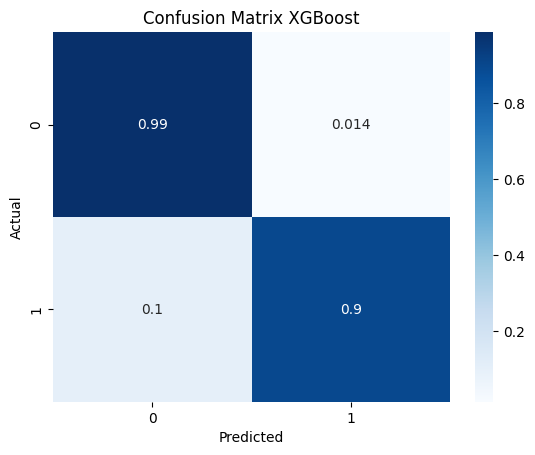

In [23]:
conf_matrix = confusion_matrix(y_test, model.predict(X_test), normalize='true')
sns.heatmap(conf_matrix, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix XGBoost')
plt.show()

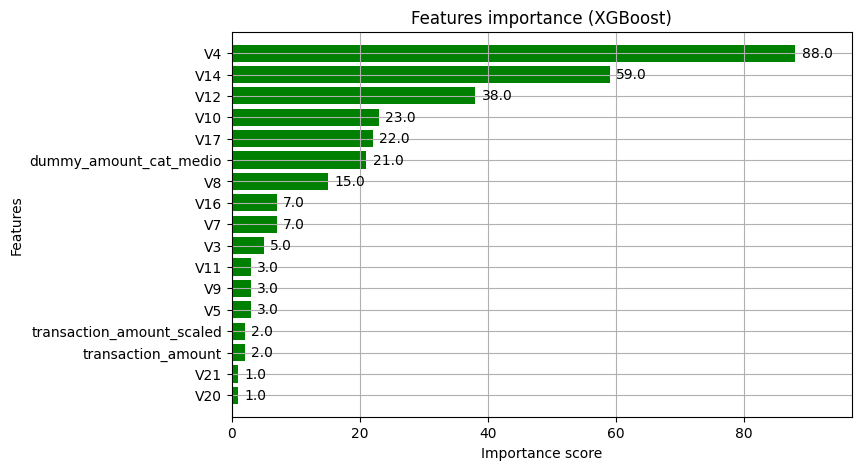

In [24]:
fig, (ax) = plt.subplots(ncols=1, figsize=(8,5))
xgb.plot_importance(model, height=0.8, title="Features importance (XGBoost)", ax=ax, color="green") 
plt.show()

## Exporting

In [25]:
import joblib
joblib.dump(model, '../../models/xgb_model.pkl')

['../../models/xgb_model.pkl']